<a href="https://colab.research.google.com/github/Nouman14-ai/Computer_Vision_Basics/blob/main/Nouman_22F_3788_A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/Nouman14-ai/Computer_Vision_Basics.git

Cloning into 'Computer_Vision_Basics'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 25 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 139.21 KiB | 1.11 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [3]:
import os
os.chdir('Computer_Vision_Basics')

# **Computer Vision Basics Assignment**
# **Name: Nouman Shabbir**
# **Roll No: 22F-3788**


# **QUESTION 1: IMAGE ENHANCEMENT**


## **Part (a): Histogram Equalization from Scratch**


### **Step 2.1 — Import Required Libraries**

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

### **Step 2.2 — Load Two Images**

In [6]:
low_img = cv2.imread('test_images/low_contrast.jpg', 0)
dark_img = cv2.imread('test_images/dark_image.jpg', 0)

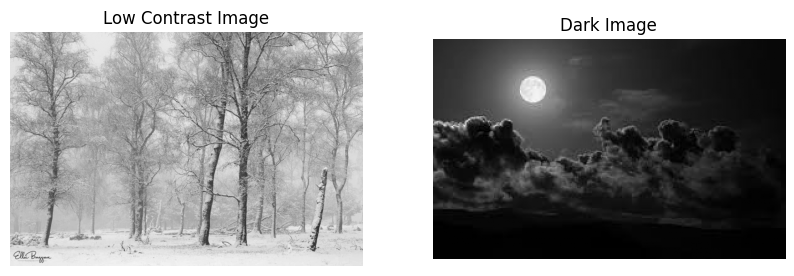

In [7]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(low_img, cmap='gray')
plt.title("Low Contrast Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(dark_img, cmap='gray')
plt.title("Dark Image")
plt.axis('off')

plt.show()

### **Step 2.3 — Implement Histogram Equalization Function (From Scratch)**

In [8]:
def histogram_equalization(image):
    # Step 1: Compute histogram
    hist = np.zeros(256)
    for pixel in image.flatten():
        hist[pixel] += 1

    # Step 2: Normalize histogram (PDF)
    pdf = hist / np.sum(hist)

    # Step 3: Compute CDF
    cdf = np.cumsum(pdf)

    # Step 4: Create transformation mapping
    mapping = np.round(cdf * 255).astype(np.uint8)

    # Step 5: Map original image pixels
    equalized_image = mapping[image]

    return equalized_image, hist, mapping

### **Step 2.4 — Apply Function**

In [9]:
low_eq, low_hist, low_map = histogram_equalization(low_img)
dark_eq, dark_hist, dark_map = histogram_equalization(dark_img)

### **Step 2.5 — Display Before/After**

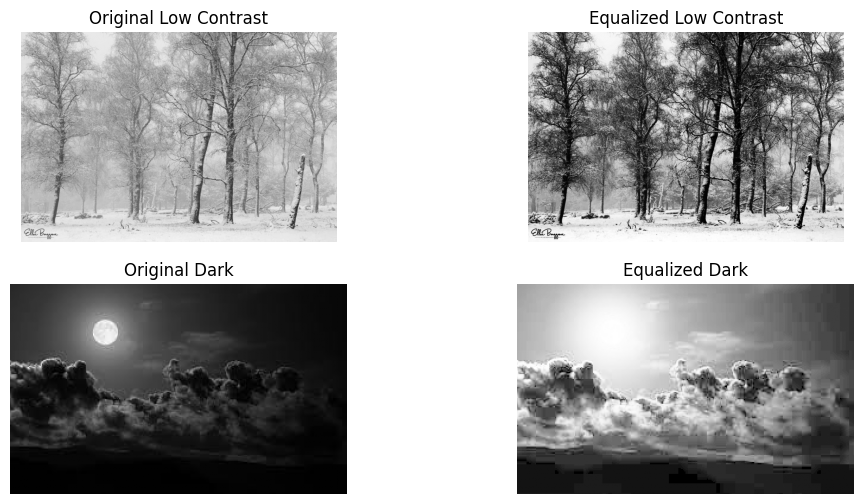

In [10]:
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(low_img, cmap='gray')
plt.title("Original Low Contrast")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(low_eq, cmap='gray')
plt.title("Equalized Low Contrast")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(dark_img, cmap='gray')
plt.title("Original Dark")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(dark_eq, cmap='gray')
plt.title("Equalized Dark")
plt.axis('off')

plt.show()

### **Step 2.6 — Print Mapping Array**

In [11]:
print("Transformation Mapping for Low Contrast Image:")
print(low_map)

Transformation Mapping for Low Contrast Image:
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   1   1   1   1   1   1   1   1   2
   2   2   2   2   3   3   3   3   3   4   4   4   4   4   5   5   5   6
   6   6   6   6   7   7   7   8   8   8   9   9  10  10  10  11  11  12
  12  13  13  14  15  15  16  16  17  18  19  20  20  21  22  23  24  25
  26  27  28  30  31  33  34  36  37  39  41  43  45  47  49  51  53  56
  59  62  65  67  70  72  75  79  83  86  90  93  96 100 104 109 113 117
 121 125 128 133 137 142 145 150 153 156 160 165 169 173 177 180 183 186
 189 192 195 197 199 201 203 206 208 211 212 215 216 218 221 223 225 227
 229 230 232 234 236 238 240 241 243 245 247 249 250 252 253 254 254 255
 255

### **Step 2.7 — Compare With OpenCV (For Verification Only)**

In [12]:
low_cv = cv2.equalizeHist(low_img)
dark_cv = cv2.equalizeHist(dark_img)

In [13]:
print("Difference (Low Image):", np.mean(np.abs(low_eq - low_cv)))
print("Difference (Dark Image):", np.mean(np.abs(dark_eq - dark_cv)))

Difference (Low Image): 0.0
Difference (Dark Image): 1.02570223601496


## **Part (b): Contrast Stretching Implementation**

### **Step 1 — Define Contrast Stretching Function**
Contrast stretching formula:
s=((r​−rmin​)/(rmax−rmin​))​×255

Where:

r = original pixel value

r_min = minimum pixel in image

r_max = maximum pixel in image

In [14]:
def contrast_stretch(image):
    r_min = np.min(image)
    r_max = np.max(image)
    stretched = ((image - r_min) / (r_max - r_min) * 255).astype(np.uint8)
    return stretched

### **Step 2 — Apply to Both Images**

In [15]:
low_stretched = contrast_stretch(low_img)
dark_stretched = contrast_stretch(dark_img)

### **Step 3 — Display Comparison**
We want to see:

Original

Histogram Equalized

Contrast Stretched

for both images.

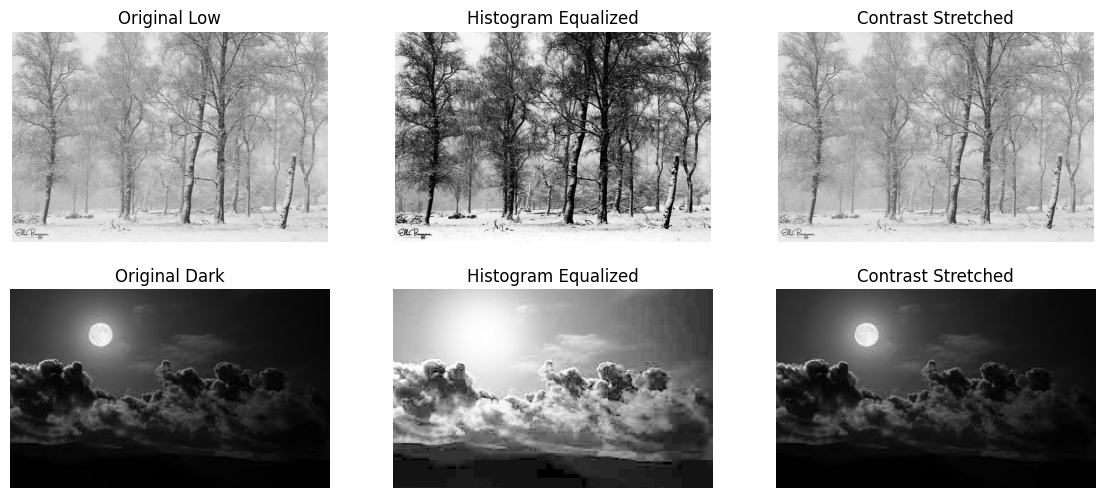

In [16]:
plt.figure(figsize=(14,6))

# Low Contrast Image
plt.subplot(2,3,1)
plt.imshow(low_img, cmap='gray')
plt.title("Original Low")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(low_eq, cmap='gray')
plt.title("Histogram Equalized")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(low_stretched, cmap='gray')
plt.title("Contrast Stretched")
plt.axis('off')

# Dark Image
plt.subplot(2,3,4)
plt.imshow(dark_img, cmap='gray')
plt.title("Original Dark")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(dark_eq, cmap='gray')
plt.title("Histogram Equalized")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(dark_stretched, cmap='gray')
plt.title("Contrast Stretched")
plt.axis('off')

plt.show()

## **Part (c): Power-Law (Gamma) Transformation**

### **Step 1 — Define Gamma Correction Function**
Power-law transformation formula:

s=c⋅r^γ

Where:

r = normalized pixel value in [0,1]

γ = gamma value

c = usually 1

In code:

##

In [17]:
def gamma_correction(image, gamma):
    # Normalize to [0,1]
    normalized = image / 255.0
    # Apply gamma
    corrected = np.power(normalized, gamma)
    # Scale back to [0,255]
    corrected_image = np.uint8(corrected * 255)
    return corrected_image

### **Step 2 — Define Gamma Values**

In [18]:
gamma_values = [0.4, 0.67, 1.0, 1.5, 2.5]

### **Step 3 — Apply Gamma Correction to Low Contrast Image**

In [19]:
low_gamma_images = [gamma_correction(low_img, g) for g in gamma_values]

### **Step 4 — Display All Results in Grid**

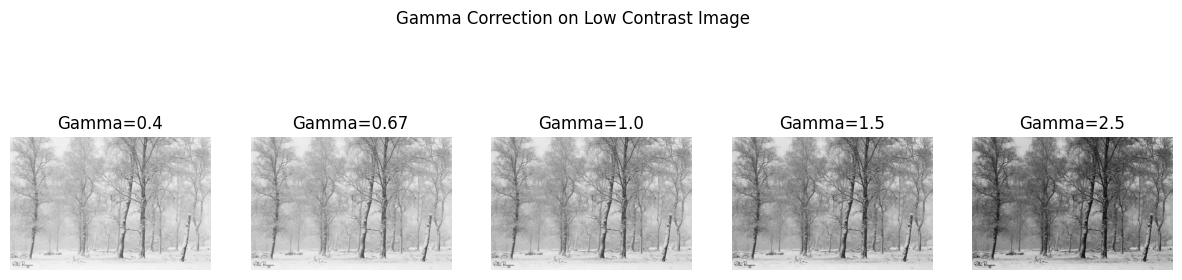

In [20]:
plt.figure(figsize=(15,4))

for i, g_img in enumerate(low_gamma_images):
    plt.subplot(1,5,i+1)
    plt.imshow(g_img, cmap='gray')
    plt.title(f"Gamma={gamma_values[i]}")
    plt.axis('off')

plt.suptitle("Gamma Correction on Low Contrast Image")
plt.show()

### **Step 5 — Repeat for Dark Image**

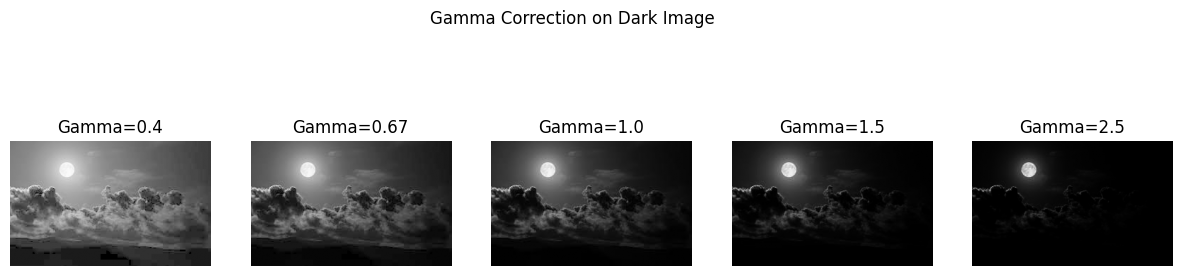

In [21]:
dark_gamma_images = [gamma_correction(dark_img, g) for g in gamma_values]

plt.figure(figsize=(15,4))

for i, g_img in enumerate(dark_gamma_images):
    plt.subplot(1,5,i+1)
    plt.imshow(g_img, cmap='gray')
    plt.title(f"Gamma={gamma_values[i]}")
    plt.axis('off')

plt.suptitle("Gamma Correction on Dark Image")
plt.show()

### **Step 6 — Observation Notes**


*   Gamma < 1 → Brightens image
*   Gamma > 1 → Darkens image
*   Gamma = 1 → No change



# **QUESTION 2: Image Filtering and Convolution**

## **Part (a): 2D Convolution from Scratch**

### **Step 1 — Define Convolution Function**
We implement 2D convolution using NumPy only.

In [22]:
import numpy as np

def convolve2d(image, kernel, padding='zero'):
    """
    2D Convolution from scratch
    :param image: input 2D image (grayscale)
    :param kernel: 2D kernel
    :param padding: 'zero', 'edge', or 'none'
    :return: convolved image
    """
    # Flip the kernel
    kernel = np.flipud(np.fliplr(kernel))

    i_h, i_w = image.shape
    k_h, k_w = kernel.shape

    # Determine padding
    if padding == 'zero':
        pad_h, pad_w = k_h//2, k_w//2
        padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    elif padding == 'edge':
        pad_h, pad_w = k_h//2, k_w//2
        padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    elif padding == 'none':
        padded = image
    else:
        raise ValueError("Padding must be 'zero', 'edge', or 'none'")

    # Determine output size
    if padding == 'none':
        output_h = i_h - k_h + 1
        output_w = i_w - k_w + 1
    else:
        output_h = i_h
        output_w = i_w

    output = np.zeros((output_h, output_w))

    # Perform convolution
    for y in range(output_h):
        for x in range(output_w):
            region = padded[y:y+k_h, x:x+k_w]
            output[y, x] = np.sum(region * kernel)

    return output

### **Step 2 — Define Test Kernels**

In [23]:
# 3x3 Box filter
box_kernel = np.ones((3,3)) / 9

# 3x3 Identity kernel
identity_kernel = np.array([[0,0,0],
                            [0,1,0],
                            [0,0,0]])

# Custom edge detection kernel
edge_kernel = np.array([[-1,-1,-1],
                        [-1,8,-1],
                        [-1,-1,-1]])

### **Step 3 — Apply Convolution on Low Contrast Image**

In [24]:
# Zero padding
conv_box_zero = convolve2d(low_img, box_kernel, padding='zero')
conv_identity_zero = convolve2d(low_img, identity_kernel, padding='zero')
conv_edge_zero = convolve2d(low_img, edge_kernel, padding='zero')

### **Step 4 — Display Results**

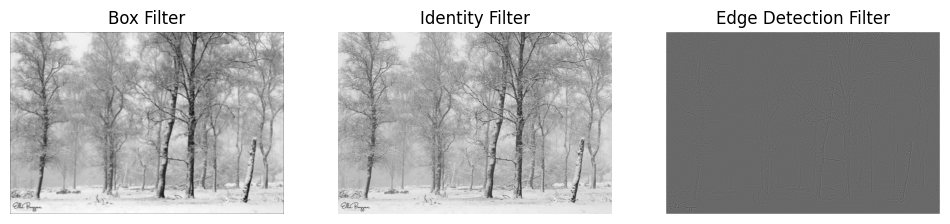

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(conv_box_zero, cmap='gray')
plt.title("Box Filter")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(conv_identity_zero, cmap='gray')
plt.title("Identity Filter")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(conv_edge_zero, cmap='gray')
plt.title("Edge Detection Filter")
plt.axis('off')

plt.show()

### **Step 5 — Compare With OpenCV filter2D (For Verification)**

In [26]:
import cv2

cv_box = cv2.filter2D(low_img, -1, box_kernel)
cv_identity = cv2.filter2D(low_img, -1, identity_kernel)
cv_edge = cv2.filter2D(low_img, -1, edge_kernel)

# Example comparison (mean absolute difference)
print("Box Filter Difference:", np.mean(np.abs(conv_box_zero - cv_box)))
print("Identity Filter Difference:", np.mean(np.abs(conv_identity_zero - cv_identity)))
print("Edge Filter Difference:", np.mean(np.abs(conv_edge_zero - cv_edge)))

Box Filter Difference: 0.6647021198830424
Identity Filter Difference: 0.0
Edge Filter Difference: 36.00974859022556


## **Part (b): Gaussian Filter Implementation**

### **Step 1 — Generate 2D Gaussian Kernel**
The 2D Gaussian formula:

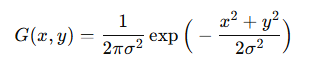


In [27]:
def gaussian_kernel(kernel_size=3, sigma=1.0):
    ax = np.arange(-(kernel_size // 2), kernel_size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2)/(2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel

### **Step 2 — Generate Example Kernels**

In [28]:
kernels = [
    gaussian_kernel(3, 1.0),
    gaussian_kernel(5, 1.5),
    gaussian_kernel(7, 2.0)
]

for i, k in enumerate(kernels):
    print(f"Kernel {i+1}:\n{k}\n")

Kernel 1:
[[0.07511361 0.1238414  0.07511361]
 [0.1238414  0.20417996 0.1238414 ]
 [0.07511361 0.1238414  0.07511361]]

Kernel 2:
[[0.01441882 0.02808402 0.0350727  0.02808402 0.01441882]
 [0.02808402 0.05470021 0.06831229 0.05470021 0.02808402]
 [0.0350727  0.06831229 0.08531173 0.06831229 0.0350727 ]
 [0.02808402 0.05470021 0.06831229 0.05470021 0.02808402]
 [0.01441882 0.02808402 0.0350727  0.02808402 0.01441882]]

Kernel 3:
[[0.00492233 0.00919613 0.01338028 0.01516185 0.01338028 0.00919613
  0.00492233]
 [0.00919613 0.01718062 0.02499766 0.02832606 0.02499766 0.01718062
  0.00919613]
 [0.01338028 0.02499766 0.03637138 0.04121417 0.03637138 0.02499766
  0.01338028]
 [0.01516185 0.02832606 0.04121417 0.04670178 0.04121417 0.02832606
  0.01516185]
 [0.01338028 0.02499766 0.03637138 0.04121417 0.03637138 0.02499766
  0.01338028]
 [0.00919613 0.01718062 0.02499766 0.02832606 0.02499766 0.01718062
  0.00919613]
 [0.00492233 0.00919613 0.01338028 0.01516185 0.01338028 0.00919613
  0.0049

### **Step 3 — Apply Gaussian Blur Using Your Convolution Function**

In [29]:
# Using 2D convolution function from Part (a)
gauss_blur_3 = convolve2d(low_img, gaussian_kernel(3, 1.0), padding='zero')
gauss_blur_5 = convolve2d(low_img, gaussian_kernel(5, 1.5), padding='zero')
gauss_blur_7 = convolve2d(low_img, gaussian_kernel(7, 2.0), padding='zero')

### **Step 4 — Display Results**

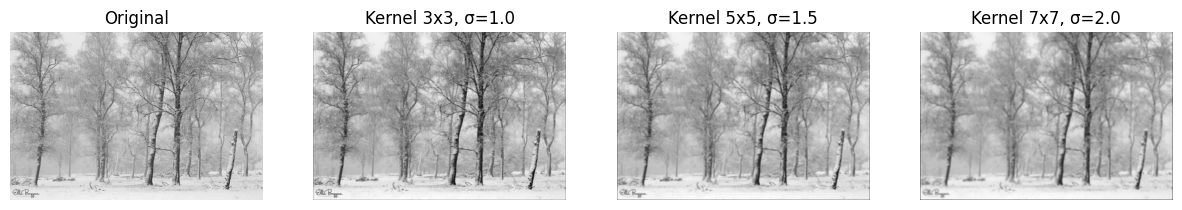

In [30]:
plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
plt.imshow(low_img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(gauss_blur_3, cmap='gray')
plt.title("Kernel 3x3, σ=1.0")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(gauss_blur_5, cmap='gray')
plt.title("Kernel 5x5, σ=1.5")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(gauss_blur_7, cmap='gray')
plt.title("Kernel 7x7, σ=2.0")
plt.axis('off')

plt.show()

### **Step 5 — Compare With OpenCV GaussianBlur**

In [31]:
cv_blur_3 = cv2.GaussianBlur(low_img, (3,3), 1.0)
cv_blur_5 = cv2.GaussianBlur(low_img, (5,5), 1.5)
cv_blur_7 = cv2.GaussianBlur(low_img, (7,7), 2.0)

print("Mean Abs Diff (3x3):", np.mean(np.abs(gauss_blur_3 - cv_blur_3)))
print("Mean Abs Diff (5x5):", np.mean(np.abs(gauss_blur_5 - cv_blur_5)))
print("Mean Abs Diff (7x7):", np.mean(np.abs(gauss_blur_7 - cv_blur_7)))

Mean Abs Diff (3x3): 0.5930241751828416
Mean Abs Diff (5x5): 0.8487032406140759
Mean Abs Diff (7x7): 1.086704617613114


### **Step 6 — Observations**

Larger kernel → stronger smoothing

Larger sigma → more blur

Smaller kernel + sigma → subtle smoothing

Gaussian preserves edges better than box filter

## **Part (c): Separable Filtering Optimization**

### **Step 1 — Generate 1D Gaussian Kernel**

Formula for 1D Gaussian:

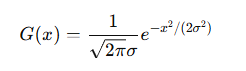

In [32]:
def gaussian_kernel_1d(kernel_size=3, sigma=1.0):
    ax = np.arange(-(kernel_size // 2), kernel_size // 2 + 1)
    kernel = np.exp(-(ax**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel

### **Step 2 — Define Separable Convolution Function**

We apply horizontal then vertical 1D convolution.

In [33]:
def separable_convolution(image, kernel_1d, padding='zero'):
    # Horizontal pass
    temp = np.zeros_like(image, dtype=np.float32)
    k = len(kernel_1d)
    pad = k // 2

    if padding == 'zero':
        padded = np.pad(image, ((0,0),(pad,pad)), mode='constant', constant_values=0)
    elif padding == 'edge':
        padded = np.pad(image, ((0,0),(pad,pad)), mode='edge')
    elif padding == 'none':
        padded = image
    else:
        raise ValueError("Invalid padding")

    # Horizontal convolution
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            if padding == 'none':
                temp[i,j] = np.sum(padded[i, j:j+k] * kernel_1d)
            else:
                temp[i,j] = np.sum(padded[i, j:j+k] * kernel_1d)

    # Vertical pass
    final = np.zeros_like(temp, dtype=np.float32)
    if padding == 'zero':
        padded_v = np.pad(temp, ((pad,pad),(0,0)), mode='constant', constant_values=0)
    elif padding == 'edge':
        padded_v = np.pad(temp, ((pad,pad),(0,0)), mode='edge')
    elif padding == 'none':
        padded_v = temp

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            if padding == 'none':
                final[i,j] = np.sum(padded_v[i:i+k, j] * kernel_1d)
            else:
                final[i,j] = np.sum(padded_v[i:i+k, j] * kernel_1d)

    return final.astype(np.uint8)

### **Step 3 — Apply Separable Gaussian Filter**

In [34]:
kernel_1d = gaussian_kernel_1d(5, 1.5)
sep_blur = separable_convolution(low_img, kernel_1d, padding='zero')

### **Step 4 — Compare With 2D Convolution**

In [35]:
import time

# 2D convolution
kernel_2d = gaussian_kernel(5, 1.5)

start = time.time()
conv_2d = convolve2d(low_img, kernel_2d, padding='zero')
time_2d = time.time() - start

# Separable
start = time.time()
conv_sep = separable_convolution(low_img, kernel_1d, padding='zero')
time_sep = time.time() - start

print(f"2D Convolution Time: {time_2d:.4f} sec")
print(f"Separable Convolution Time: {time_sep:.4f} sec")
print("Difference (mean abs):", np.mean(np.abs(conv_2d - conv_sep)))

2D Convolution Time: 4.0219 sec
Separable Convolution Time: 4.7860 sec
Difference (mean abs): 0.49815444705011175


### **Step 5 — Display Result**

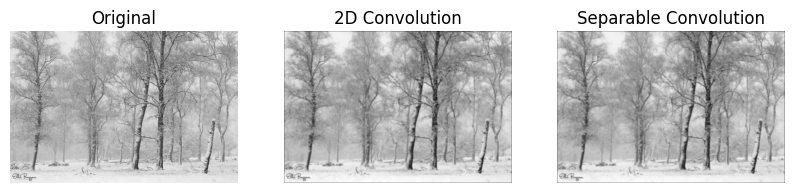

In [36]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(low_img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(conv_2d, cmap='gray')
plt.title("2D Convolution")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(conv_sep, cmap='gray')
plt.title("Separable Convolution")
plt.axis('off')

plt.show()

### **Step 6 — Observations**

Separable convolution reduces computation significantly

Results are numerically almost identical to 2D convolution

Use this in large images or real-time filtering

# **Question 3: Edge Detection and Gradient Computation**

## **Part (a): Image Gradients Implementation**


### **Step 1 — Define Gradient Kernels**

In [37]:
# Central difference
kernel_central_x = np.array([[1,0,-1]])
kernel_central_y = np.array([[1],[0],[-1]])

# Sobel
kernel_sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
kernel_sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

# Prewitt
kernel_prewitt_x = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
kernel_prewitt_y = np.array([[-1,-1,-1],[0,0,0],[1,1,1]])

# Roberts cross
kernel_roberts_x = np.array([[1,0],[0,-1]])
kernel_roberts_y = np.array([[0,1],[-1,0]])

### **Step 2 — Compute Gradients**

In [38]:
def gradient_magnitude_direction(Gx, Gy):
    magnitude = np.sqrt(Gx**2 + Gy**2)
    direction = np.arctan2(Gy, Gx)
    return magnitude, direction

# Example: Sobel
Gx_sobel = convolve2d(low_img, kernel_sobel_x, padding='zero')
Gy_sobel = convolve2d(low_img, kernel_sobel_y, padding='zero')
mag_sobel, dir_sobel = gradient_magnitude_direction(Gx_sobel, Gy_sobel)

### **Step 3 — Visualize**

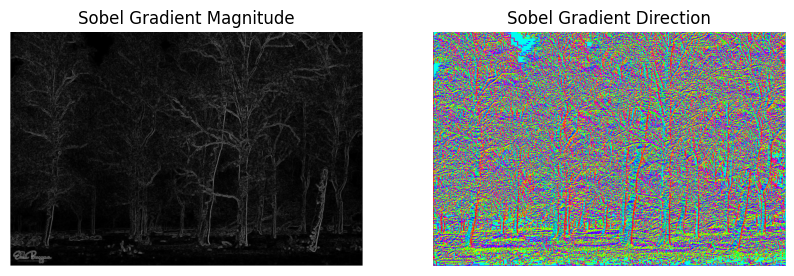

In [40]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(mag_sobel, cmap='gray')
plt.title("Sobel Gradient Magnitude")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(dir_sobel, cmap='hsv')
plt.title("Sobel Gradient Direction")
plt.axis('off')
plt.show()

## **Part (b): Canny Edge Detector Implementation**

### **Step 1 — Gaussian Smoothing**

In [41]:
kernel = gaussian_kernel(5, 1.5)
smoothed = convolve2d(low_img, kernel, padding='zero')

### **Step 2 — Gradient Computation**
Use Sobel operator:

In [42]:
Gx = convolve2d(smoothed, kernel_sobel_x, padding='zero')
Gy = convolve2d(smoothed, kernel_sobel_y, padding='zero')
magnitude, direction = gradient_magnitude_direction(Gx, Gy)

### **Step 3 — Non-Maximum Suppression**


*   Thin edges by keeping local maxima along gradient direction
*   Create a function non_max_suppression(magnitude, direction)



In [49]:
import numpy as np

def non_max_suppression(magnitude, direction):
    """
    Thin edges by suppressing non-maximum pixels along gradient direction
    :param magnitude: Gradient magnitude
    :param direction: Gradient direction in radians
    :return: Thinned edge image
    """
    H, W = magnitude.shape
    Z = np.zeros((H,W), dtype=np.float32)
    angle = direction * 180. / np.pi
    angle[angle < 0] += 180

    for i in range(1,H-1):
        for j in range(1,W-1):
            try:
                q = 255
                r = 255

                # 0 degrees
                if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                    q = magnitude[i, j+1]
                    r = magnitude[i, j-1]
                # 45 degrees
                elif (22.5 <= angle[i,j] < 67.5):
                    q = magnitude[i+1, j-1]
                    r = magnitude[i-1, j+1]
                # 90 degrees
                elif (67.5 <= angle[i,j] < 112.5):
                    q = magnitude[i+1, j]
                    r = magnitude[i-1, j]
                # 135 degrees
                elif (112.5 <= angle[i,j] < 157.5):
                    q = magnitude[i-1, j-1]
                    r = magnitude[i+1, j+1]

                if (magnitude[i,j] >= q) and (magnitude[i,j] >= r):
                    Z[i,j] = magnitude[i,j]
                else:
                    Z[i,j] = 0

            except IndexError as e:
                pass

    return Z

### **Step 4 — Hysteresis Thresholding**


*   Apply two thresholds: low and high
*   Strong edges → keep
*   Weak edges → keep only if connected to strong edges



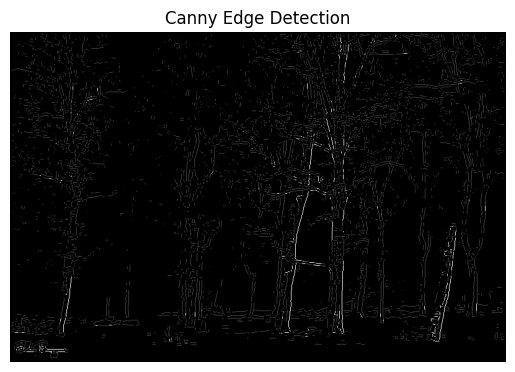

In [50]:
edges_canny = hysteresis(non_max_suppression(magnitude, direction), 50, 150)

plt.imshow(edges_canny, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()

In [51]:
def hysteresis(img, low_thresh, high_thresh):
    strong = 255
    weak = 75
    res = np.zeros_like(img)
    # Apply thresholds
    res[img >= high_thresh] = strong
    res[(img >= low_thresh) & (img < high_thresh)] = weak
    # Edge linking
    # Implement simple 8-connected neighbor check
    return res

### **Step 5 — Visualization & Comparison**

Compare with OpenCV:

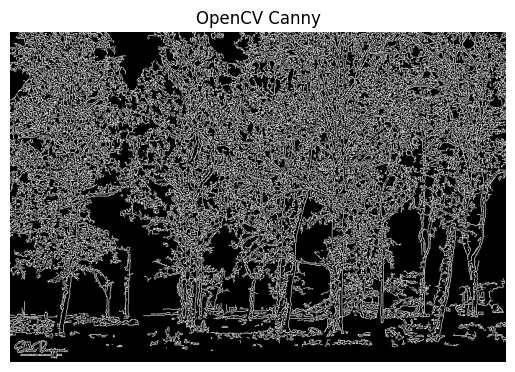

In [52]:
canny_cv = cv2.Canny(low_img, 50, 150)
plt.imshow(canny_cv, cmap='gray')
plt.title("OpenCV Canny")
plt.axis('off')
plt.show()

## **Part (c): Edge Detection Comparison**

### **Step 1 — Simple Gradient Threshold**

In [53]:
threshold = 100
edges_simple = (mag_sobel > threshold).astype(np.uint8) * 255

### **Step 2 — Sobel Threshold**

In [54]:
edges_sobel = (mag_sobel > threshold).astype(np.uint8) * 255

### **Step 3 — Laplacian of Gaussian (LoG)**

In [55]:
log_kernel = np.array([[0,0,-1,0,0],
                       [0,-1,-2,-1,0],
                       [-1,-2,16,-2,-1],
                       [0,-1,-2,-1,0],
                       [0,0,-1,0,0]])
edges_log = convolve2d(low_img, log_kernel, padding='zero')
edges_log = (edges_log > 0).astype(np.uint8) * 255

### **Step 4 — Canny**


In [56]:
edges_canny = hysteresis(non_max_suppression(magnitude, direction), 50, 150)

### **Step 5 — Visualization**

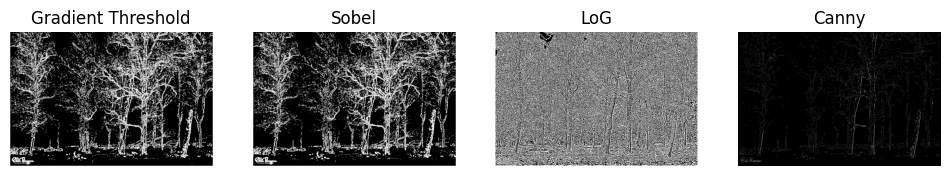

In [57]:
plt.figure(figsize=(12,6))
titles = ["Gradient Threshold","Sobel","LoG","Canny"]
images = [edges_simple, edges_sobel, edges_log, edges_canny]

for i, img in enumerate(images):
    plt.subplot(1,4,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

### **Step 6 — Noise Comparison**

In [58]:
noise = np.random.normal(0, 25, low_img.shape)
noisy_img = np.clip(low_img + noise, 0, 255).astype(np.uint8)